<a href="https://colab.research.google.com/github/mundundan-star/online-retail-customer-analytics/blob/main/6.0%20Predicting_Customer_Life_Time_Value_(CLTV).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine, inspect, text
from google.colab import userdata

engine = create_engine(userdata.get('NEON_DATABASE_URL'))

# importing metrics data before august 31st and merging customer spend and frequency after 31st for testing

query = """
WITH train_data AS (
SELECT "CustomerID",
   "Frequency",
   "Recency",
   "TotalRevenue"/"Frequency" AS "AOV",
   "ObservedLifeSpan",
   "Tenure",
   "ProductDiversity"

FROM v_customer_metrics),

test_data AS
(SELECT "CustomerID",
    COUNT(DISTINCT "InvoiceDate") AS "Frequency_test",
    AVG("Revenue") AS "AOV_test"
FROM v_clean_sales_analytics
WHERE "InvoiceDate" > '2011-08-31'
GROUP BY 1),

segments AS
(SELECT "CustomerID",
    "KSegment"
FROM customer_segment_labels)

SELECT *
FROM train_data
LEFT JOIN segments
USING("CustomerID")
LEFT JOIN test_data
USING("CustomerID")
"""

df = pd.read_sql(text(query), con = engine).fillna(0)
df.head()

,CustomerID,Frequency,Recency,AOV,ObservedLifeSpan,Tenure,ProductDiversity,KSegment,Frequency_test,AOV_test
0,12346.0,1,325,77183.600000,0,325,1,2,0.0,0.000000
1,12347.0,5,129,4.501387,238,367,82,1,2.0,26.192069
2,12348.0,3,248,17.705238,110,358,22,0,1.0,103.333333
3,12350.0,1,310,19.670588,0,310,17,0,0.0,0.000000
4,12352.0,4,262,10.275066,34,296,26,0,3.0,20.090000


In [48]:

import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.decomposition import PCA
from sklearn.compose import TransformedTargetRegressor

from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

# Setup partitions using your log-transformed frequency target
X = df.drop(["Frequency_test", "AOV_test"], axis=1)
features = X.columns
X = X.values
y = df['Frequency_test']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

# Models configuration matching your suite
models = [
    ("Linear_R", LinearRegression()),
    ("Lasso", Lasso(alpha=0.1)),
    ("Ridge", Ridge(alpha=1.0)),
    ("ElasticNet", ElasticNet(alpha=0.1, l1_ratio=0.5)),
    ("Random_F", RandomForestRegressor(n_estimators=300, max_depth=6, random_state=42)),
    ("Gradient_B", GradientBoostingRegressor(n_estimators=300, max_depth=6, random_state=42)),
    ("KNeighbors", KNeighborsRegressor(n_neighbors=5)),
    ("Support_V", SVR(C=10.0, epsilon=1.0)),
    ("Xgboost", XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.05, random_state=42)),
    ("lightgbm", LGBMRegressor(n_estimators=300, max_depth=6, learning_rate=0.05, random_state=42, verbose=-1))
]

# Shared Preprocessing Transformer Layers
scaler = StandardScaler()

mae_results = []
rmse_results = []
model_name = []


for name, model in models:
    wrapped_model = TransformedTargetRegressor(
                   regressor = model,
                   func = np.log1p,
                   inverse_func = np.expm1)
    pipeline = make_pipeline(scaler, model)
    kf = KFold(n_splits=5, shuffle=True, random_state= 42)

    mae_scores = cross_val_score(pipeline, X_train, y_train, cv=kf, n_jobs=-1, scoring='neg_mean_absolute_error')
    rmse_scores = cross_val_score(pipeline, X_train, y_train, cv=kf, n_jobs=-1, scoring='neg_root_mean_squared_error')

    mae_results.append(-mae_scores)
    rmse_results.append(-rmse_scores)
    model_name.append(name)

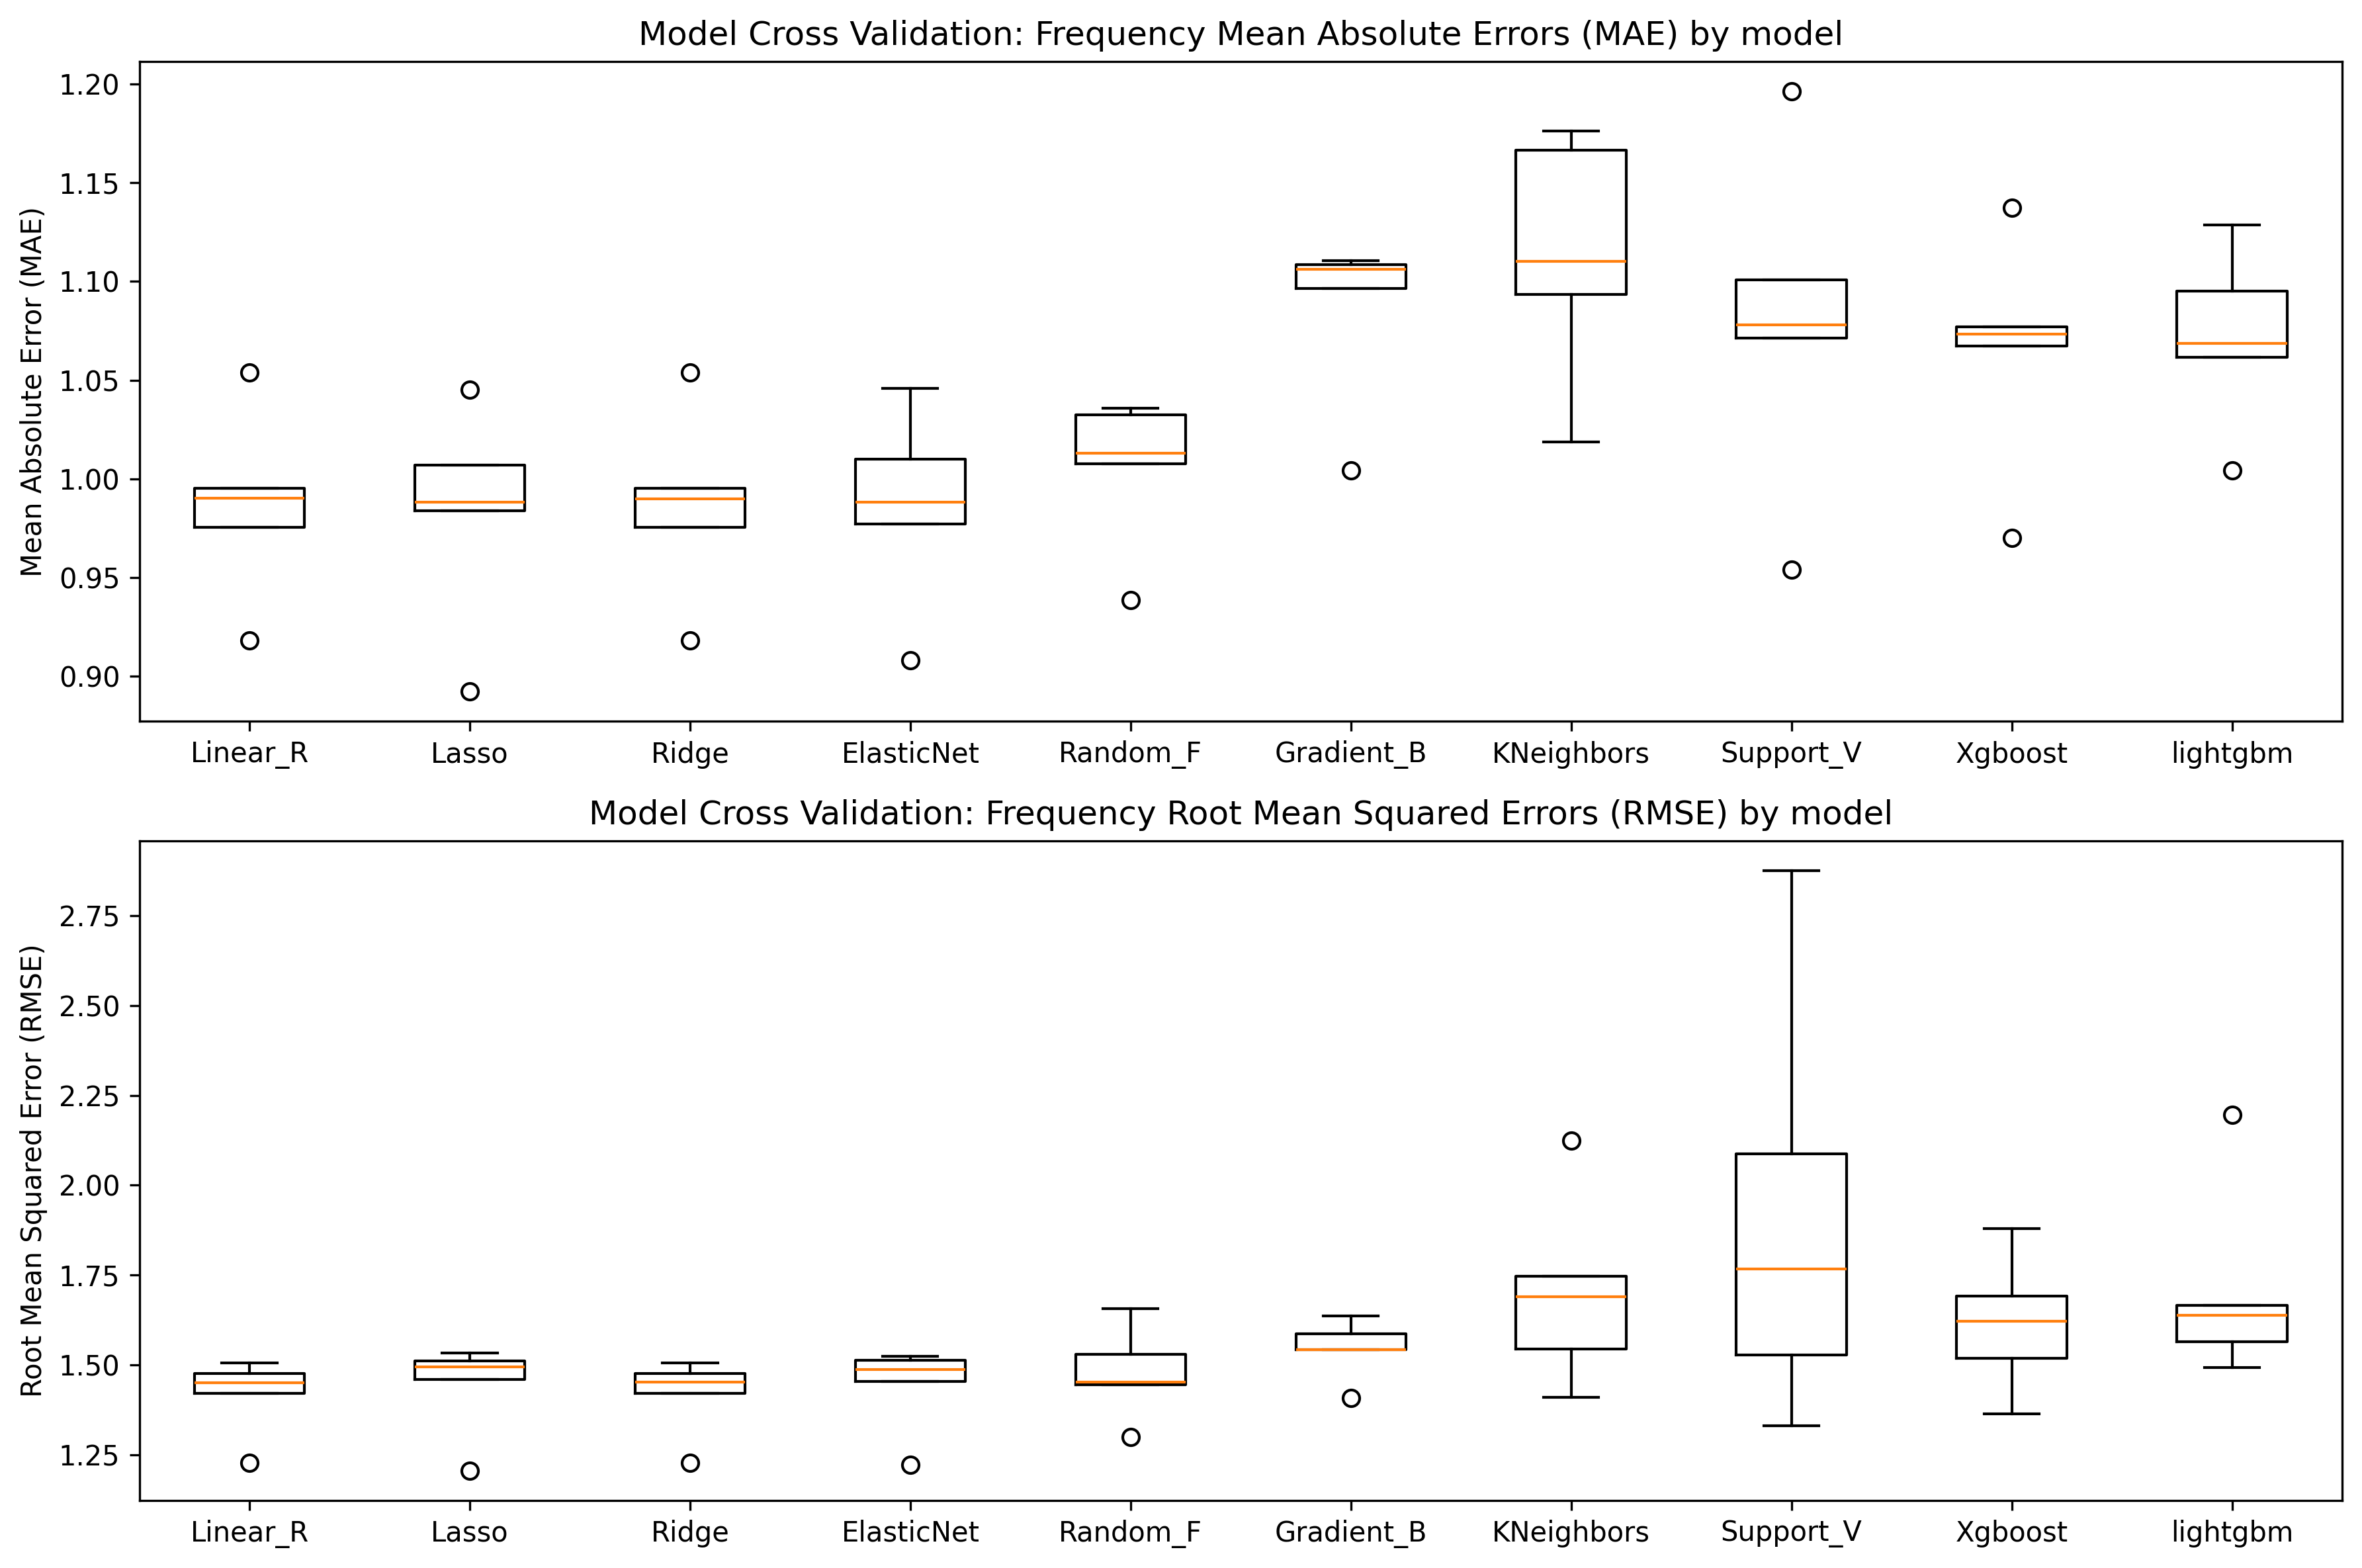

In [49]:
fig, (ax1, ax2) = plt.subplots(2,1, figsize = (12,8), dpi = 300)
ax1.boxplot(mae_results, tick_labels = model_name)
ax1.set_ylabel("Mean Absolute Error (MAE)")
ax1.set_title("Model Cross Validation: Frequency Mean Absolute Errors (MAE) by model")

ax2.boxplot(rmse_results, tick_labels = model_name)
ax2.set_ylabel("Root Mean Squared Error (RMSE)")
ax2.set_title("Model Cross Validation: Frequency Root Mean Squared Errors (RMSE) by model")
plt.tight_layout()
plt.show()